# House Price Prediction

Build a model that predicts house sale prices based on the property features in the dataset via size, rooms, location type, or condition.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

## 1. Dataset Exploration

In [2]:
df = pd.read_excel('./data/HousePricePrediction.xlsx')
df.shape

(2919, 13)

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   str    
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   str    
 5   BldgType      2919 non-null   str    
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   str    
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), str(4)
memory usage: 352.3 KB


In [5]:
df['SalePrice'].isnull().sum()

np.int64(1459)

In [6]:
df = df[df['SalePrice'].notnull()].reset_index(drop=True)
df.shape

(1460, 13)

In [7]:
# Id column is just a row identifier, not useful for prediction
df = df.drop(columns=['Id'])

In [8]:
df.isnull().sum()

MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

Numerical vs categorical features:

In [10]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.drop('SalePrice')
cat_cols = df.select_dtypes(include=['object']).columns
print('numerical:', list(num_cols))
print('categorical:', list(cat_cols))

numerical: ['MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF2', 'TotalBsmtSF']
categorical: ['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']


C:\Users\USER\AppData\Local\Temp\ipykernel_33524\2621416900.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [11]:
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

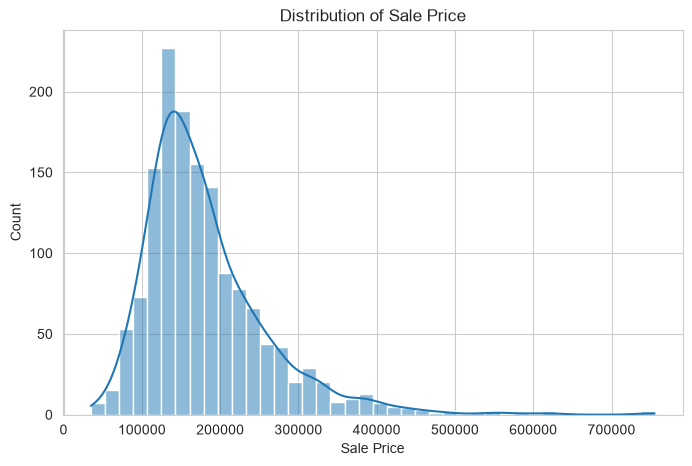

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], bins=40, kde=True)
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price')
plt.show()

Price distribution is right-skewed, most houses fall in the 100k-250k range with
a long tail of more expensive ones.

## 2. Data Preprocessing

Handle missing values

In [13]:
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum().sum()

np.int64(0)

In [14]:
df = df.drop_duplicates()
df.shape

(1460, 12)

### Outliers

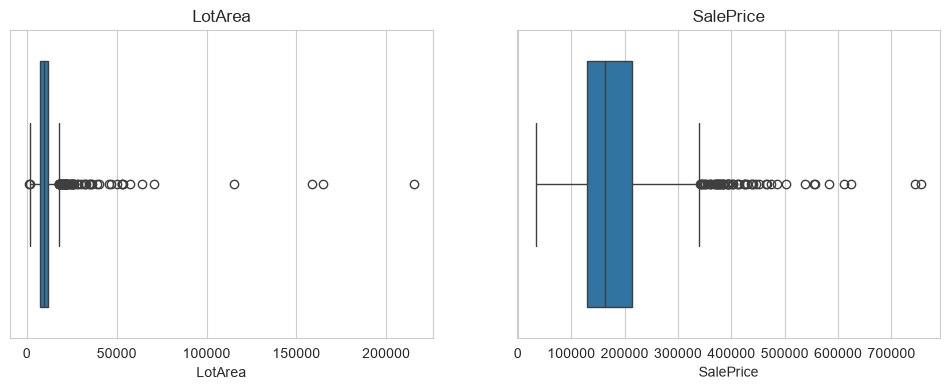

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(x=df['LotArea'], ax=axes[0])
axes[0].set_title('LotArea')
sns.boxplot(x=df['SalePrice'], ax=axes[1])
axes[1].set_title('SalePrice')
plt.show()

In [16]:
lot_cap = df['LotArea'].quantile(0.99)
df = df[df['LotArea'] <= lot_cap]
df.shape

(1445, 12)

### Encoding categorical variables

In [17]:
df_encoded = pd.get_dummies(df, columns=list(cat_cols), drop_first=True)
df_encoded.shape

(1445, 34)

### Train/test split

In [18]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['SalePrice'])
y = df_encoded['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((1156, 33), (289, 33))

### Scaling numerical features

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

## 3. Exploratory Data Analysis

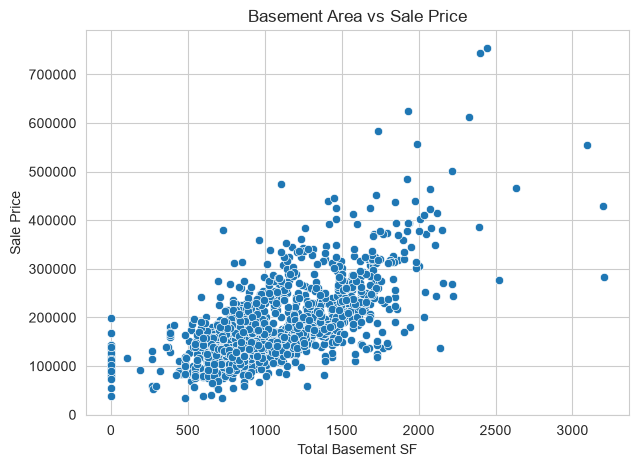

In [20]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df['TotalBsmtSF'], y=df['SalePrice'])
plt.title('Basement Area vs Sale Price')
plt.xlabel('Total Basement SF')
plt.ylabel('Sale Price')
plt.show()

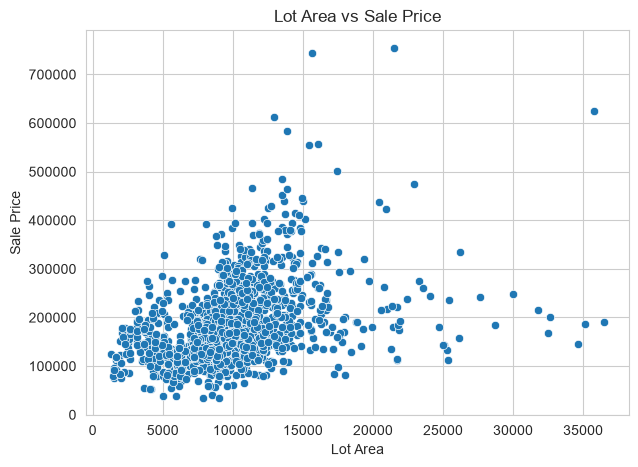

In [21]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df['LotArea'], y=df['SalePrice'])
plt.title('Lot Area vs Sale Price')
plt.xlabel('Lot Area')
plt.ylabel('Sale Price')
plt.show()

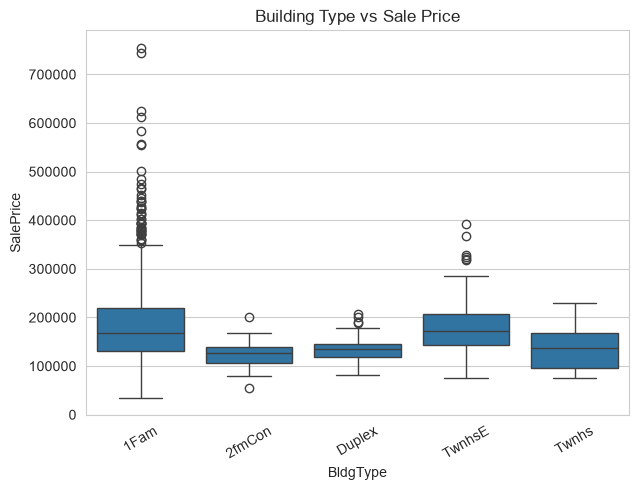

In [22]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df['BldgType'], y=df['SalePrice'])
plt.title('Building Type vs Sale Price')
plt.xticks(rotation=30)
plt.show()

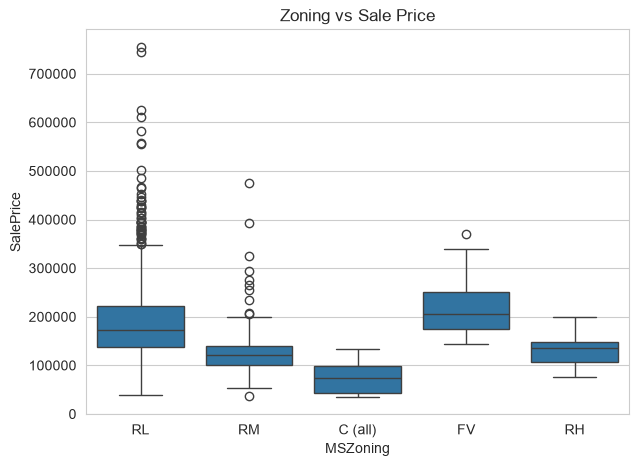

In [23]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df['MSZoning'], y=df['SalePrice'])
plt.title('Zoning vs Sale Price')
plt.show()

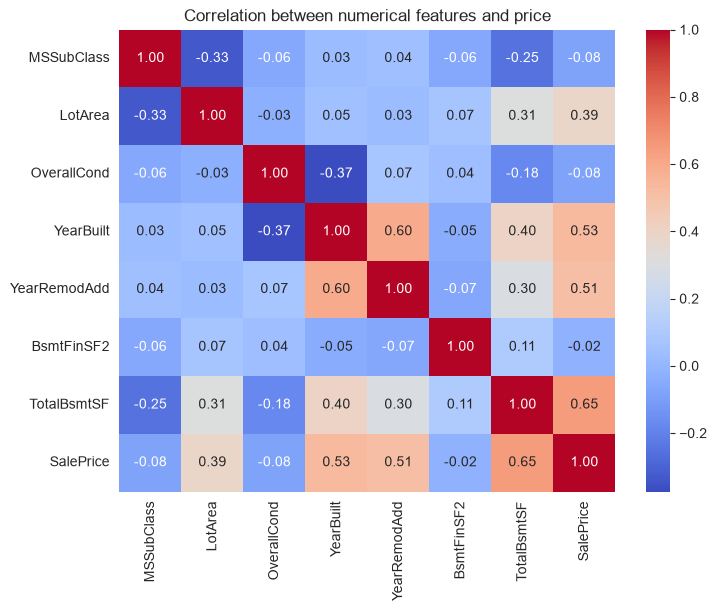

In [24]:
plt.figure(figsize=(8,6))
corr = df[list(num_cols) + ['SalePrice']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation between numerical features and price')
plt.show()

## 4. Model Training

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression()
lr.fit(X_train, y_train)

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

## 5. Model Evaluation

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(model, name):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    return {'model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

results = [
    evaluate(lr, 'Linear Regression'),
    evaluate(dt, 'Decision Tree'),
    evaluate(rf, 'Random Forest'),
]

results_df = pd.DataFrame(results).set_index('model')
results_df

,MAE,MSE,RMSE,R2
model,,,,
Linear Regression,28718.318405,1.650199e+09,40622.638491,0.637448
Decision Tree,30514.974048,2.253512e+09,47471.169614,0.504899
Random Forest,19990.103937,9.865107e+08,31408.767111,0.783262


- **MAE** - average absolute difference between predicted and actual price, in dollars.
- **MSE** - similar but squares the errors, so bigger mistakes get punished more.
- **RMSE** - square root of MSE, brings it back to dollar units and is easier to interpret than MSE.
- **R²** - how much of the variance in price the model explains (1.0 = perfect, 0 = no better than guessing the mean).

In [27]:
best_model = rf
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(10)

TotalBsmtSF            0.361743
YearBuilt              0.337990
LotArea                0.131119
MSSubClass             0.056746
YearRemodAdd           0.043334
OverallCond            0.023509
Exterior1st_BrkFace    0.007136
Exterior1st_Wd Sdng    0.006178
LotConfig_Inside       0.004195
Exterior1st_VinylSd    0.003919
dtype: float64

## 6. Model Saving

In [28]:
import joblib
import os

os.makedirs('model', exist_ok=True)

joblib.dump(rf, 'model/house_price_model.pkl')
joblib.dump(scaler, 'model/scaler.pkl')
joblib.dump(list(num_cols), 'model/num_cols.pkl')
joblib.dump(list(X_train.columns), 'model/feature_columns.pkl')

cat_options = {col: sorted(df[col].dropna().unique().tolist()) for col in cat_cols}
joblib.dump(cat_options, 'model/cat_options.pkl')

os.listdir('model')

['cat_options.pkl',
 'feature_columns.pkl',
 'house_price_model.pkl',
 'num_cols.pkl',
 'scaler.pkl']